In [1]:
!pip install yfinance stable-baselines3 shimmy gym==0.26.2 gym-notices --quiet

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import torch
import gym
from gym import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
import warnings
warnings.filterwarnings("ignore")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.7/721.7 kB 51.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 20.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
tickers = ["AAPL", "MSFT", "SPY"]
raw = yf.download(tickers, start="2015-01-01", end="2023-01-01", group_by="ticker")

def pick_price(df):
    for c in ["Adj Close", "Close"]:
        if c in df.columns:
            return df[c]
    raise RuntimeError("price column missing again")

prices = pd.concat([pick_price(raw[t]) for t in tickers], axis=1)
prices.columns = tickers
prices = prices.dropna()

[*********************100%***********************]  3 of 3 completed


In [3]:
rets = prices.pct_change()

log_r = np.log1p(rets.replace([np.inf, -np.inf], 0))
vol20 = rets.rolling(20).std()
mom60 = rets.rolling(60).mean()

X = pd.concat([rets, log_r, vol20, mom60], axis=1)
X = X.replace([np.inf, -np.inf], 0).dropna()
rets = rets.loc[X.index]

In [4]:
class TradingGame(gym.Env):
    """
    Portfolio allocator with turnover and cost penalty.
    Not trying to be a perfect market simulator.
    """

    def __init__(self, r, feats):
        super().__init__()
        self.r = r.values
        self.feats = feats.values
        self.n = r.shape[1]

        self.action_space = spaces.Box(0, 1, shape=(self.n,), dtype=np.float32)
        self.observation_space = spaces.Box(-np.inf, np.inf, shape=(self.feats.shape[1],), dtype=np.float32)

        # added after noticing crazy weight flipping
        self.fee = 0.001
        self.turnover_penalty = 0.002

        self.reset()

    def reset(self):
        self.t = 0
        self.w_prev = np.ones(self.n) / self.n
        return self.feats[self.t]

    def step(self, act):
        w = np.clip(act, 0, 1)
        w = w / (w.sum() + 1e-8)

        turnover = np.abs(w - self.w_prev).sum()
        cost = turnover * self.turnover_penalty + self.fee

        gross = np.dot(self.r[self.t], w)
        reward = gross - cost

        self.w_prev = w.copy()
        self.t += 1

        done = self.t >= len(self.feats) - 1
        obs = self.feats[self.t]

        return obs, reward, done, {"turnover": turnover}

In [5]:
env = DummyVecEnv([lambda: TradingGame(rets, X)])

model = PPO(
    "MlpPolicy",
    env,
    verbose=0,
    learning_rate=3e-4,
    n_steps=1024,
    batch_size=256,
)

model.learn(20000)
model.save("ppo_alloc_v3")

In [7]:
def rollout_agent(m, r, feats):
    env_raw = TradingGame(r, feats)
    obs = env_raw.reset()

    rets_list = []
    weights_list = []

    for _ in range(len(r)):
        act, _ = m.predict(obs, deterministic=True)
        obs, reward, done, info = env_raw.step(act)

        rets_list.append(reward)
        weights_list.append(env_raw.w_prev.copy())

        if done:
            break

    return np.array(rets_list), np.array(weights_list)

rl_rets, rl_w = rollout_agent(model, rets, X)
rl_equity = (1 + rl_rets).cumprod()

In [8]:
bench = prices["SPY"].loc[X.index]
bench = bench.iloc[:len(rl_equity)]
bench_eq = bench / bench.iloc[0]

In [9]:
def metrics(eq, r):
    ann = 252
    total = eq[-1] - 1
    cagr = eq[-1] ** (ann / len(eq)) - 1
    vol = np.std(r) * np.sqrt(ann)
    sharpe = np.mean(r) / (np.std(r) + 1e-8) * np.sqrt(ann)
    dd = eq / np.maximum.accumulate(eq) - 1
    return total, cagr, vol, sharpe, dd.min()

m_rl = metrics(rl_equity, rl_rets)
bench_r = bench_eq.pct_change().fillna(0).values
m_bench = metrics(bench_eq.values, bench_r)

print("\nRL vs Benchmark")
print("Total Return:", m_rl[0], "|", m_bench[0])
print("CAGR:", m_rl[1], "|", m_bench[1])
print("Sharpe:", m_rl[3], "|", m_bench[3])
print("MaxDD:", m_rl[4], "|", m_bench[4])


RL vs Benchmark
Total Return: 0.9025557523661947 | 1.1406469593883553
CAGR: 0.0865345343666939 | 0.10319167019028708
Sharpe: 0.4652369527987831 | 0.6182103989149841
MaxDD: -0.35621573980372623 | -0.33717260841362795


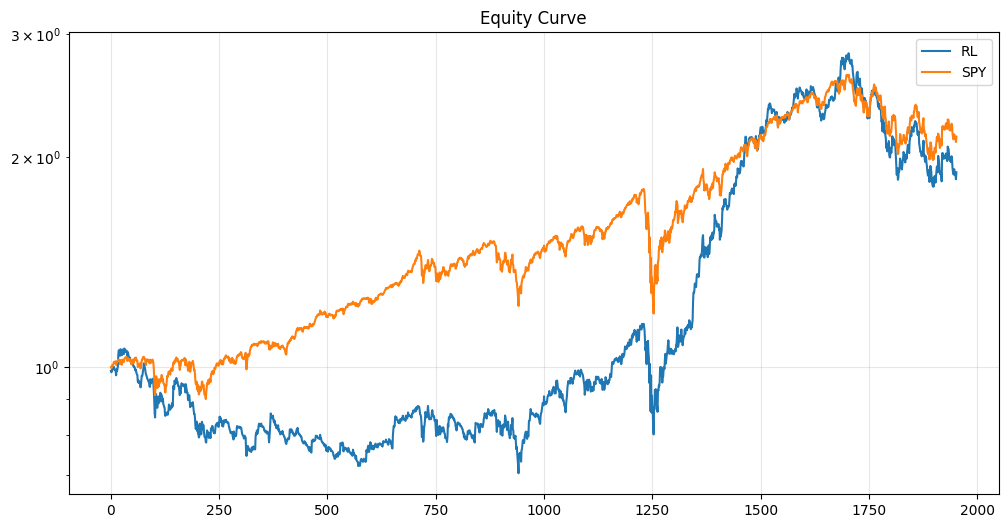

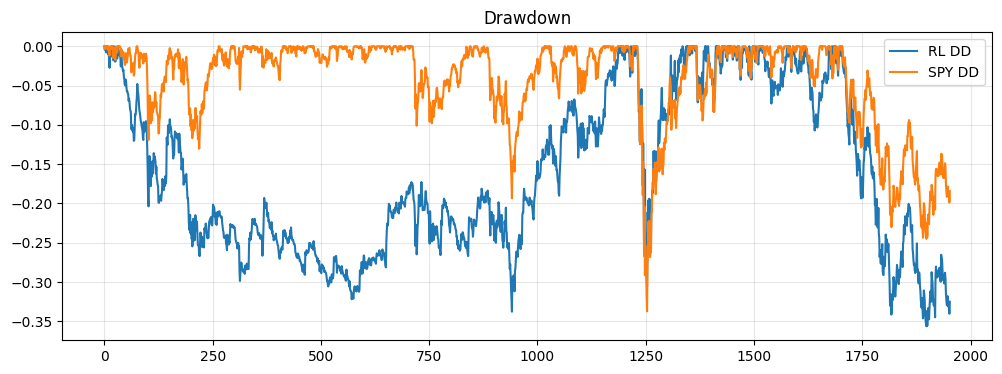

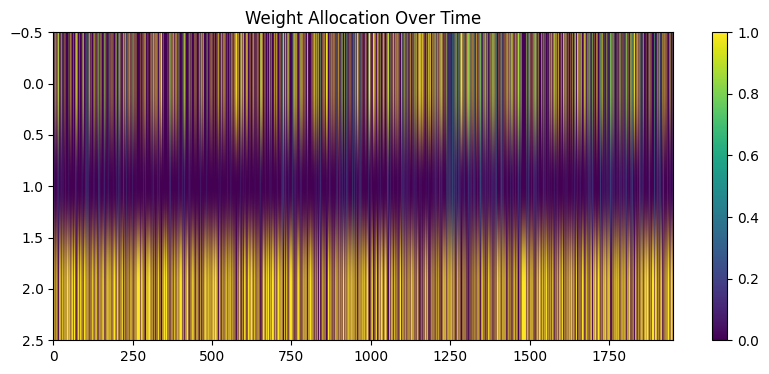

In [10]:
plt.figure(figsize=(12,6))
plt.plot(rl_equity, label="RL")
plt.plot(bench_eq.values, label="SPY")
plt.yscale("log")
plt.legend()
plt.title("Equity Curve")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(12,4))
dd_rl = rl_equity / np.maximum.accumulate(rl_equity) - 1
dd_b = bench_eq.values / np.maximum.accumulate(bench_eq.values) - 1
plt.plot(dd_rl, label="RL DD")
plt.plot(dd_b, label="SPY DD")
plt.legend()
plt.title("Drawdown")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10,4))
plt.imshow(rl_w.T, aspect="auto", cmap="viridis")
plt.title("Weight Allocation Over Time")
plt.colorbar()
plt.show()